In [2]:
!pip install pandas numpy matplotlib seaborn scipy

  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)

   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pand


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Load dữ liệu đã clean từ LAB04
df = pd.read_csv("LAB04_cleaned_retail_sample.csv")
df.head()

,order_id,order_date,customer_id,gender,region,category,product,quantity,unit_price,discount,customer_age,status,quantity_missing_flag,order_month,revenue,age_group
0,O001,2025-01-03,C001,male,North,Technology,Laptop,1.0,1250.0,0.05,35.0,Delivered,0,2025-01,1187.50,26-35
1,O002,2025-01-05,C002,male,South,Furniture,Office Chair,2.0,180.0,0.10,42.0,Delivered,0,2025-01,324.00,36-50
2,O003,2025-01-07,C003,male,North,Office Supplies,Printer Paper,5.0,12.5,0.00,NaN,Delivered,0,2025-01,62.50,NaN
3,O004,NaN,C004,female,Central,Technology,Headset,3.0,45.0,0.05,29.0,Delayed,0,NaT,128.25,26-35
4,O005,2025-01-11,C005,female,South,Furniture,Desk,1.0,350.0,0.15,31.0,Delivered,0,2025-01,297.50,26-35


In [2]:
print(df.dtypes)
vars_ = ["revenue", "customer_age"]

order_id                     str
order_date                   str
customer_id                  str
gender                       str
region                       str
category                     str
product                      str
quantity                 float64
unit_price               float64
discount                 float64
customer_age             float64
status                       str
quantity_missing_flag      int64
order_month                  str
revenue                  float64
age_group                    str
dtype: object


In [3]:
summary = df[vars_].describe().T  

summary = summary.rename(columns={
    "25%": "Q1", "50%": "median", "75%": "Q3"
})

summary["missing_%"] = (df[vars_].isna().mean() * 100).round(2)
summary["skewness"] = df[vars_].apply(lambda x: skew(x.dropna())).round(3)
summary["kurtosis"] = df[vars_].apply(lambda x: kurtosis(x.dropna())).round(3)

# Sắp xếp lại cột đúng thứ tự đề yêu cầu
summary = summary[["count","missing_%","mean","median","std","min","Q1","Q3","max","skewness","kurtosis"]]
summary

,count,missing_%,mean,median,std,min,Q1,Q3,max,skewness,kurtosis
revenue,12.0,0.0,348.4125,310.75,348.253091,0.0,58.875,454.3,1187.5,1.162,0.762
customer_age,9.0,25.0,33.0000,33.00,6.284903,22.0,29.000,37.0,42.0,-0.205,-0.767


In [4]:
summary.to_csv("lab05_summary_stats.csv")

# Vẽ histogram 

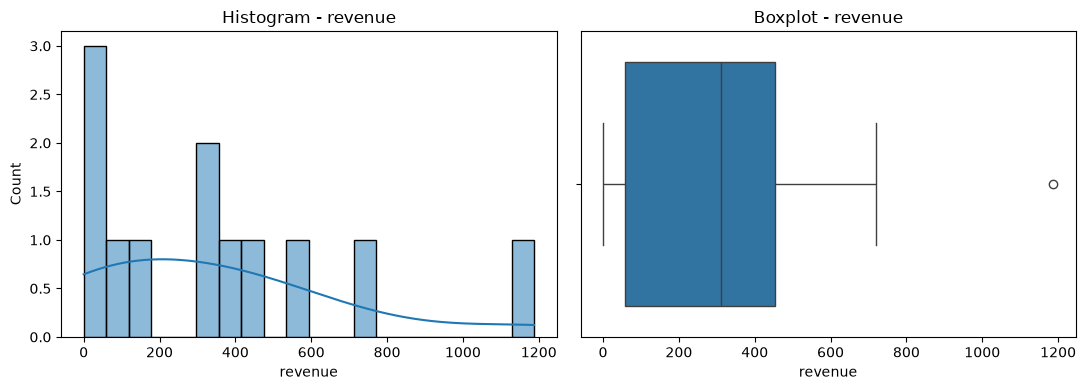

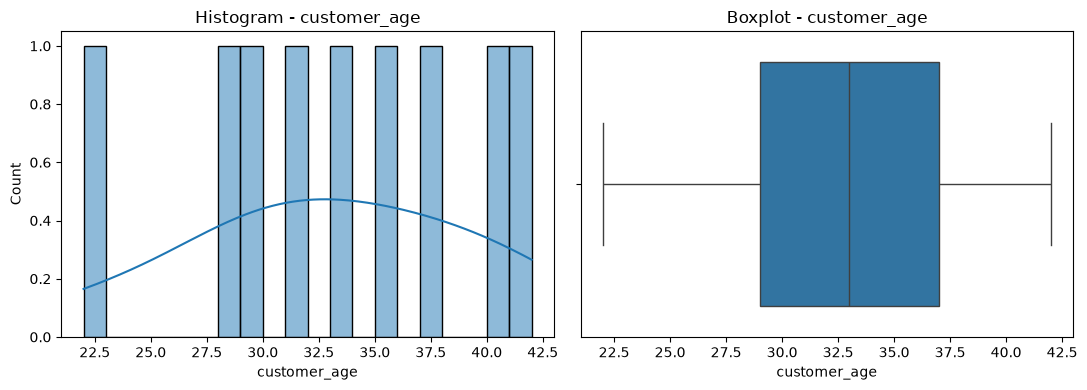

In [5]:
for col in vars_:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.histplot(df[col].dropna(), bins=20, kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram - {col}")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.savefig(f"lab05_{col}_dist.png", dpi=150)
    plt.show()

## Diễn giải 
### Revenue:
* Revenue có mean (348.41) cao hơn median (310.75), cùng với skewness = 1.162 cho thấy phân phối lệch phải khá rõ
* Phần lớn đơn hàng tập trung ở mức thấp đến trung bình (dưới ~450) nhưng một vài đơn hàng giá trị rất cao kéo trung bình lên. Boxplot xác nhận có 1 điểm nằm ngoài ngưỡng trên (Q3 + 1.5×IQR ≈ 1047), tương ứng với đơn hàng ~1187.5 — đây là outlier cần xem xét riêng chứ không nên loại bỏ vội.
* Về mặt kinh doanh, nếu đây là dữ liệu bán lẻ, khả năng cao đây là đơn hàng số lượng lớn hoặc khách B2B chứ không hẳn lỗi nhập liệu. Vì median thấp hơn mean khá nhiều, nên dùng median khi báo cáo "giá trị đơn hàng điển hình" để tránh đánh giá quá cao hiệu quả kinh doanh trung bình. Tuy nhiên với cỡ mẫu chỉ 12 quan sát, kết luận về hình dạng phân phối này còn rất yếu và cần thêm dữ liệu trước khi khẳng định chắc chắn.

### customer_age:
* Customer_age có mean và median trùng nhau (33), skewness gần 0 (-0.205) cho thấy phân phối tương đối đối xứng, không lệch rõ về phía nào.
* Kurtosis âm (-0.767) cho thấy phân phối khá phẳng — tuổi khách hàng trải đều trong khoảng 22–42 hơn là tập trung quanh một đỉnh duy nhất, phù hợp với hình dạng quan sát được trên histogram. Boxplot không ghi nhận outlier nào, nên không có dấu hiệu bất thường về tuổi.
* Tuy nhiên, điểm đáng lưu ý nhất của biến này là tỷ lệ missing lên tới 25% (chỉ 9/12 quan sát có giá trị) — đây là vấn đề cần ưu tiên xử lý hơn là hình dạng phân phối, vì nếu dữ liệu thiếu không phải "missing at random" (ví dụ khách hàng lớn tuổi ít điền form hơn) thì các thống kê trên có thể bị sai lệch. Trước khi dùng biến này cho phân tích sâu hơn, cần kiểm tra nguyên nhân missing và cân nhắc imputation hoặc loại trừ có justification.


# So sánh bin= 10, 20, 30

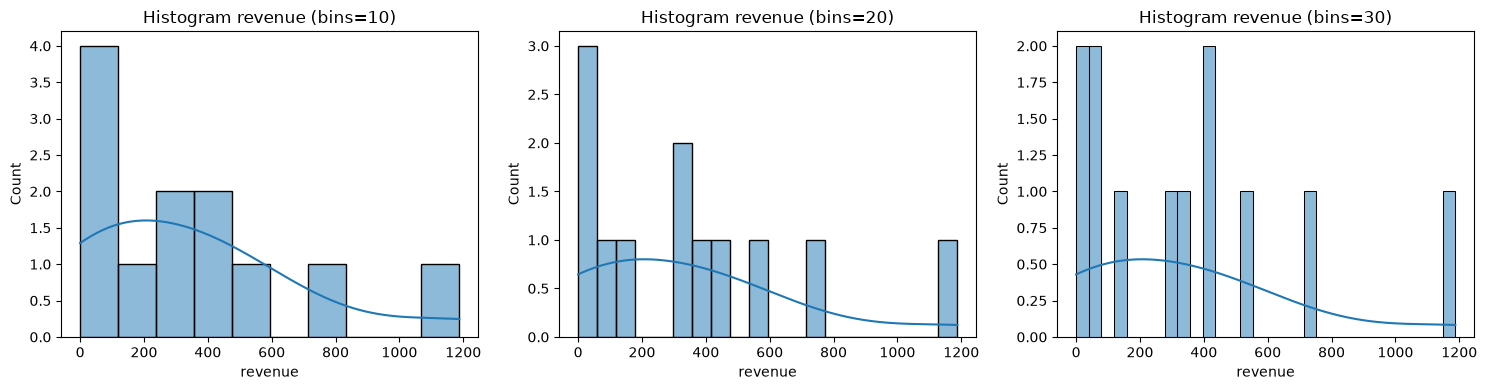

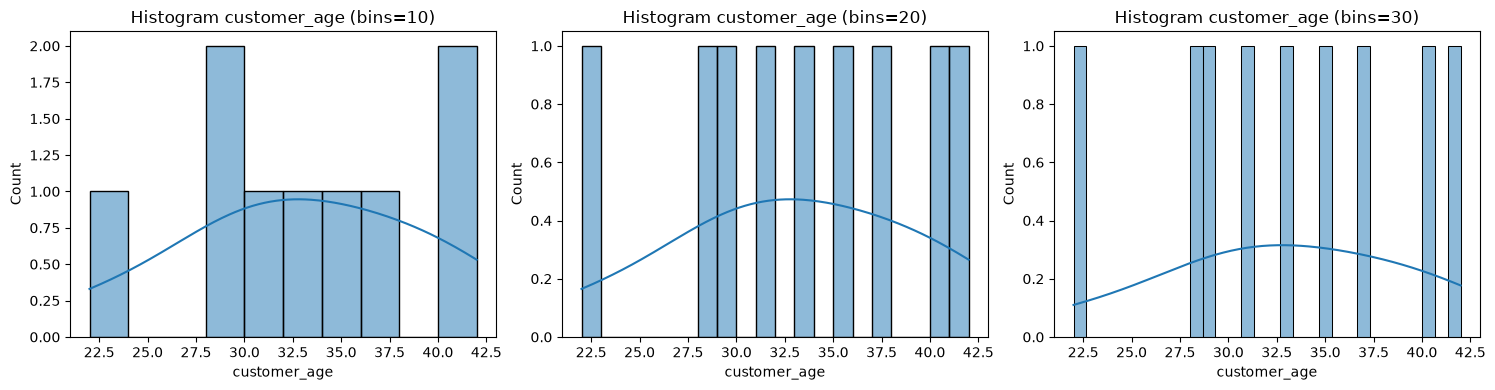

In [10]:
for col in vars_:
    # Tạo 1 hàng gồm 3 ô đồ thị tương ứng với 3 mức bins (10, 20, 30)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Vòng lặp duyệt qua các ô đồ thị và các mức bins tương ứng
    for ax, b in zip(axes, [10, 20, 30]):
        sns.histplot(df[col].dropna(), bins=b, ax=ax, kde=True)  # Thêm kde=True nếu muốn có đường cong
        ax.set_title(f"Histogram {col} (bins={b})")
    
    plt.tight_layout()
    plt.savefig(f"lab05_{col}_bin_comparison.png", dpi=150)
    plt.show()

## Ghi chú bin sensitivity 

### revenue:
* hình dạng khá ổn định qua 3 mức bin — cả 3 đều cho thấy phần lớn giá trị tập trung ở mức thấp (gần 0-400) và một đuôi dài về phía giá trị cao, đặc biệt điểm ~1150-1200 luôn tách biệt rõ dù bin nào. 
→ Kết luận lệch phải là đáng tin cậy, không phải do chọn bin.
* Tuy nhiên vẫn có khoảng trống ở giữa ~200 khi càng về các bins cuối. Điều này cần phân tích thêm.
### customer_age: 
* hình dạng phân phối thay đổi đáng kể theo số bin:  ở bins=10, dữ liệu trông như có nhiều cụm tách biệt, nhưng khi tăng bins, các khoảng trống này thu hẹp lại và phân phối trông đều hơn. Vì biến này chỉ có 9 quan sát, đây là dấu hiệu cho thấy các "cụm" quan sát được ở bins thấp nhiều khả năng là artifact của cỡ mẫu nhỏ chứ không phản ánh pattern thật trong dữ liệu.

* ---> hình dạng lệch phải giữ ổn định qua cả 3 mức bin, nên kết luận về skew của revenue đáng tin cậy hơn.